In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


In [2]:
data=pd.read_csv('UberDataset.csv')

In [3]:
df=data.copy()

In [4]:
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1151,12/31/2016 13:24,12/31/2016 13:42,Business,Kar?chi,Unknown Location,3.9,Temporary Site
1152,12/31/2016 15:03,12/31/2016 15:38,Business,Unknown Location,Unknown Location,16.2,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


In [5]:
df.isna().sum()

START_DATE      0
END_DATE        1
CATEGORY        1
START           1
STOP            1
MILES           0
PURPOSE       503
dtype: int64

In [9]:
df.nunique()

START_DATE    1155
END_DATE      1154
CATEGORY         2
START          177
STOP           188
MILES          257
PURPOSE         10
dtype: int64

In [10]:
df.isna().sum() *100 /len(df)

START_DATE     0.000000
END_DATE       0.086505
CATEGORY       0.086505
START          0.086505
STOP           0.086505
MILES          0.000000
PURPOSE       43.512111
dtype: float64

43 % missing values are in PURPOSE


In [11]:
df.duplicated().sum()

np.int64(1)

In [22]:
df.drop_duplicates(inplace=True)
df.drop(1155,inplace=True)

In [23]:
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1150,12/31/2016 1:07,12/31/2016 1:14,Business,Kar?chi,Kar?chi,0.7,Meeting
1151,12/31/2016 13:24,12/31/2016 13:42,Business,Kar?chi,Unknown Location,3.9,Temporary Site
1152,12/31/2016 15:03,12/31/2016 15:38,Business,Unknown Location,Unknown Location,16.2,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site


In [24]:
df.isna().sum()

START_DATE      0
END_DATE        0
CATEGORY        0
START           0
STOP            0
MILES           0
PURPOSE       502
dtype: int64

In [25]:
df.loc[df['PURPOSE'].isna(),['CATEGORY','START','STOP','PURPOSE']]

,CATEGORY,START,STOP,PURPOSE
1,Business,Fort Pierce,Fort Pierce,NaN
32,Business,Whitebridge,Lake Wellingborough,NaN
85,Personal,Whitebridge,Northwoods,NaN
86,Personal,Northwoods,Tanglewood,NaN
87,Personal,Tanglewood,Preston,NaN
...,...,...,...,...
1065,Business,Unknown Location,Unknown Location,NaN
1066,Business,Unknown Location,Unknown Location,NaN
1069,Business,Islamabad,Unknown Location,NaN
1071,Business,Unknown Location,Rawalpindi,NaN


In [ ]:
df['CATEGORY'].value_counts()

,CATEGORY,count
0,Business,1077
1,Personal,77


<Axes: xlabel='CATEGORY', ylabel='count'>

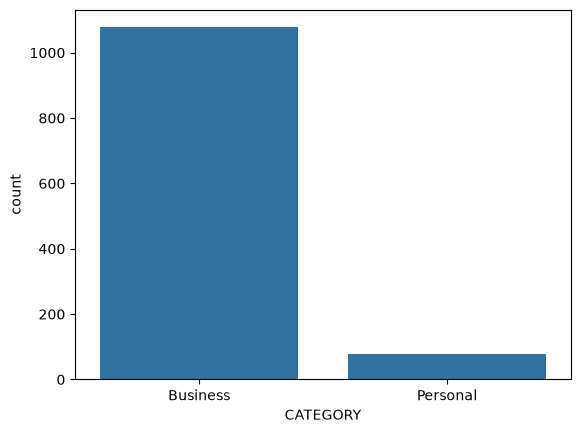

In [ ]:
sns.countplot(df,x='CATEGORY')

In [ ]:
# Trying to understand or maybe find relation between CAtegory and Purpose

# here both category and Purpose are objects and categorical 
# Using crosstab
# Put CATEGORY on the rows and PURPOSE on the columns, then count how many times each combination occurs.

In [30]:
pd.crosstab(df['CATEGORY'],df['PURPOSE'])

PURPOSE,Airport/Travel,Between Offices,Charity ($),Commute,Customer Visit,Errand/Supplies,Meal/Entertain,Meeting,Moving,Temporary Site
CATEGORY,,,,,,,,,,
Business,3,18,0,0,101,128,160,186,0,50
Personal,0,0,1,1,0,0,0,0,4,0


THis returns a dataframe so we can further plot

In [ ]:
reln_cat_pur=pd.crosstab(df['CATEGORY'],df['PURPOSE'],normalize='index')*100  # changing to percentage
reln_cat_pur

PURPOSE,Airport/Travel,Between Offices,Charity ($),Commute,Customer Visit,Errand/Supplies,Meal/Entertain,Meeting,Moving,Temporary Site
CATEGORY,,,,,,,,,,
Business,0.464396,2.786378,0.000000,0.000000,15.634675,19.814241,24.767802,28.79257,0.000000,7.739938
Personal,0.000000,0.000000,16.666667,16.666667,0.000000,0.000000,0.000000,0.00000,66.666667,0.000000


Text(0.5, 1.0, 'Reln Between Category and Purpose')

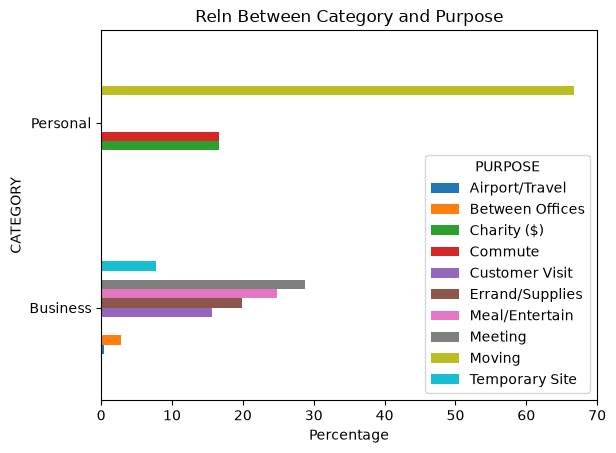

In [39]:
reln_cat_pur.plot(kind='barh')
plt.xlabel('Percentage')
plt.title("Reln Between Category and Purpose")

WE can see  more than 60% Personal Category People has travel purpose Moving ( pesonal cateory is only 77 whereas business is 1077)
and highest Business cateory is 30% who are traveling for meetings
( only statistical Assumption)
# so we cant just fill the values with the relevant ffill() and bfill()  about 50% of the purpise is missing

# Investigae missingness by category

In [40]:
pd.crosstab(
    df['CATEGORY'],
    df['PURPOSE'].isna(),
    normalize='index'
) * 100

PURPOSE,False,True
CATEGORY,,
Business,59.981430,40.018570
Personal,7.792208,92.207792


For Business rides:

About 40% of PURPOSE values are missing.

For Personal rides:

About 92% of PURPOSE values are missing.

That means the missingness is extremely high, especially for Personal rides.

So filling those missing values with a guessed purpose could seriously distort your EDA.

# lets just fill with 'UNKNOWN'


In [44]:
df['PURPOSE']=df['PURPOSE'].fillna('UNKNOWN')

In [45]:
df.isna().sum()

START_DATE    0
END_DATE      0
CATEGORY      0
START         0
STOP          0
MILES         0
PURPOSE       0
dtype: int64

In [46]:
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,UNKNOWN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1150,12/31/2016 1:07,12/31/2016 1:14,Business,Kar?chi,Kar?chi,0.7,Meeting
1151,12/31/2016 13:24,12/31/2016 13:42,Business,Kar?chi,Unknown Location,3.9,Temporary Site
1152,12/31/2016 15:03,12/31/2016 15:38,Business,Unknown Location,Unknown Location,16.2,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site


In [51]:
df['START']=df['START'].str.replace("?","a")

In [52]:
df['STOP']=df['STOP'].str.replace("?","a")

In [53]:
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,UNKNOWN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1150,12/31/2016 1:07,12/31/2016 1:14,Business,Karachi,Karachi,0.7,Meeting
1151,12/31/2016 13:24,12/31/2016 13:42,Business,Karachi,Unknown Location,3.9,Temporary Site
1152,12/31/2016 15:03,12/31/2016 15:38,Business,Unknown Location,Unknown Location,16.2,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site


In [54]:
df[['START_DATE','END_DATE']]

,START_DATE,END_DATE
0,01-01-2016 21:11,01-01-2016 21:17
1,01-02-2016 01:25,01-02-2016 01:37
2,01-02-2016 20:25,01-02-2016 20:38
3,01-05-2016 17:31,01-05-2016 17:45
4,01-06-2016 14:42,01-06-2016 15:49
...,...,...
1150,12/31/2016 1:07,12/31/2016 1:14
1151,12/31/2016 13:24,12/31/2016 13:42
1152,12/31/2016 15:03,12/31/2016 15:38
1153,12/31/2016 21:32,12/31/2016 21:50


In [55]:
df[['START_DATE','END_DATE']].dtypes

START_DATE    object
END_DATE      object
dtype: object

In [56]:
df['START_DATE']=pd.to_datetime(df['START_DATE'],format='mixed')

In [58]:
df['END_DATE']=pd.to_datetime(df['END_DATE'],format='mixed')

In [59]:
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,UNKNOWN
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1150,2016-12-31 01:07:00,2016-12-31 01:14:00,Business,Karachi,Karachi,0.7,Meeting
1151,2016-12-31 13:24:00,2016-12-31 13:42:00,Business,Karachi,Unknown Location,3.9,Temporary Site
1152,2016-12-31 15:03:00,2016-12-31 15:38:00,Business,Unknown Location,Unknown Location,16.2,Meeting
1153,2016-12-31 21:32:00,2016-12-31 21:50:00,Business,Katunayake,Gampaha,6.4,Temporary Site


In [60]:
df[['START_DATE','END_DATE']].dtypes

START_DATE    datetime64[ns]
END_DATE      datetime64[ns]
dtype: object

In [ ]:
df['END_DATE']-df['START_DATE'] # it gives us result in time delta 0 days 00:06:00  so we convert them to seconds and againa minutes 

0      0 days 00:06:00
1      0 days 00:12:00
2      0 days 00:13:00
3      0 days 00:14:00
4      0 days 01:07:00
             ...      
1150   0 days 00:07:00
1151   0 days 00:18:00
1152   0 days 00:35:00
1153   0 days 00:18:00
1154   0 days 01:43:00
Length: 1154, dtype: timedelta64[ns]

In [64]:
df['RIDE_DURATION(MIN)']=(df['END_DATE']-df['START_DATE']).dt.total_seconds() /60 

In [65]:
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,RIDE_DURATION,RIDE_DURATION(MIN)
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,6.0,6.0
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,UNKNOWN,12.0,12.0
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,13.0,13.0
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,14.0,14.0
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,67.0,67.0
...,...,...,...,...,...,...,...,...,...
1150,2016-12-31 01:07:00,2016-12-31 01:14:00,Business,Karachi,Karachi,0.7,Meeting,7.0,7.0
1151,2016-12-31 13:24:00,2016-12-31 13:42:00,Business,Karachi,Unknown Location,3.9,Temporary Site,18.0,18.0
1152,2016-12-31 15:03:00,2016-12-31 15:38:00,Business,Unknown Location,Unknown Location,16.2,Meeting,35.0,35.0
1153,2016-12-31 21:32:00,2016-12-31 21:50:00,Business,Katunayake,Gampaha,6.4,Temporary Site,18.0,18.0
